# LSN Exercises 12
## Convolutional neural networks


Gabriele Borroni (14768A)

---
### MNIST with Keras

The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).

The MNIST dataset comprises $70000$ handwritten digits, each of which comes in a square image, divided into a $28\times 28$ pixel grid. Every pixel can take on $256$ gradation of the gray color, interpolating between white and black, and hence each data point assumes any value in the set $\{0,1,\dots,255\}$. Since there are $10$ categories in the problem, corresponding to the ten digits, this problem represents a generic **classification task**. 

The task was submitted to **one hot encoding**, which consists in generating an output vector of shape 10 filled with zeros, and only one integer value (1) is assigned in the index corresponding to the relative handwritten number.

Below it is shown an example of a MNIST dataset image.

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)
X_train shape: (60000, 784)
X_test shape: (10000, 784)

an example of a data point with label 4


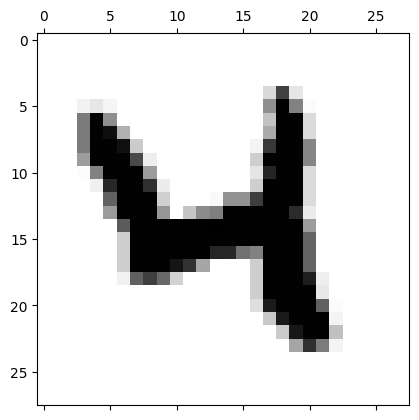

... and with label [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] after to_categorical

X_train shape: (60000, 784)
Y_train shape: (60000, 10)


In [1]:

#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True' #This is needed in my Anaconda+MacOsX installation; leave it commented.
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
# reshape data, it could depend on Keras backend
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print()

# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]
X_train /= 255
X_test /= 255

# look at an example of data point
print('an example of a data point with label', Y_train[20])
# matshow: display a matrix in a new figure window
plt.matshow(X_train[20,:].reshape(28,28),cmap='binary')
plt.show()

# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)
print('... and with label', Y_train[20], 'after to_categorical')
print()
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

In the first part, the classification task is performed using a **deep neural network** with two layers (400, 100 neurons respectively).

The one hot encoding allows to use the **categorical crossentropy loss function**, which is defined as:
$$
L(y, \hat{y}) \;=\; - \sum_{i=1}^C y_i \, \log \hat{y}_i
$$

Also **dropout** has been included to regularize the training: at each step, 50% of the neurons are turned off randomly.

In [2]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

def create_DNN():
    # instantiate model
    #il layer di input non è un layer esplicito, ma è implicito nella definizione dell’input shape del primo layer Dense.
    model = Sequential()
    # add a dense all-to-all relu layer
    model.add(Dense(400,input_shape=(img_rows*img_cols,), activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

Model architecture created successfully!


In [3]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

def compile_model():
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=SGD(),
                  metrics=['acc'])
    return model

print('Model compiled successfully and ready to be trained.')

Model compiled successfully and ready to be trained.


In [4]:
# training parameters
batch_size = 32
epochs = 50

# create the deep neural net
model_DNN = compile_model()

# train DNN and store training info in history
history = model_DNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=True,#stampa la barra di caricamento
          validation_data=(X_test, Y_test))

Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.7781 - loss: 0.7556 - val_acc: 0.9157 - val_loss: 0.3129
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8907 - loss: 0.3876 - val_acc: 0.9315 - val_loss: 0.2416
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9118 - loss: 0.3114 - val_acc: 0.9404 - val_loss: 0.2039
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 890us/step - acc: 0.9239 - loss: 0.2694 - val_acc: 0.9467 - val_loss: 0.1786
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9336 - loss: 0.2358 - val_acc: 0.9523 - val_loss: 0.1588
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 926us/step - acc: 0.9414 - loss: 0.2121 - val_acc: 0.9570 - val_loss: 0.1456
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 905us/step - acc: 0.9462 - loss: 0.1931 - val_acc: 0.9591 - val_loss: 0.1316
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 918us/step - acc: 0.9499 - loss: 0.1766 - val_acc: 0.9621 - val_loss: 0.1221
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - acc: 0.9814 - loss: 0.0604

Test loss: 0.060391105711460114
Test accuracy: 0.9814000129699707


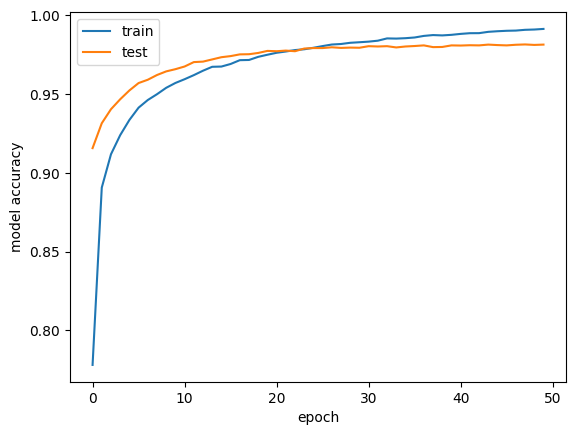

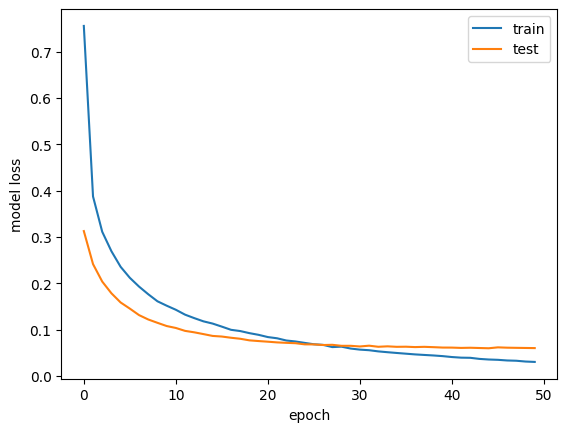

In [5]:
# evaluate model
score = model_DNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

## 12.2: CNN

In this section, the same classification task as before has been tackled by using a **convolutional neural network (CNN)**.

 A CNN:
- Uses **Convolutional layers**: Filters (kernels) slide locally over the input by making convolution operations with it, this is used to capture **local patterns** (edges, shapes, textures).
- Uses **Pooling layers** (e.g. MaxPooling), which reduce dimensionality while keeping relevant info.
- after the dimensionality reduction and feature extraction done by conv2D and maxPooling layers, the compressed data is flattened and submitted to a regular MLP, with a final output layer of dimension 10 (classification).

The main advantage of using CNN is that they leverage spatial feature, so that they work better with images.



In [6]:
# you will need the following for Convolutional Neural Networks
from keras.layers import Flatten, Conv2D, MaxPooling2D

# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


The CNN used for this task is made up by two convolutional layers (the first one is used to extract global features, while the second captures more local correlations, which is why it has twice the filters of the first one) followed by other two MaxPooling layers, which compress the data.

After the flattening layer, there is a fully connected one with 128 neurons and the final otput one with 10. 25% dropout has been implemented in the first Dense layer.

The problem is the same as before, so the loss is again the categorical crossentropy.

In [21]:

def create_CNN():
    # instantiate model
    model = Sequential()
   
    model.add(Conv2D(32, kernel_size=(5, 5),
                     activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(filters=64, kernel_size=(5,5), activation= 'relu'))

    model.add(MaxPooling2D(pool_size=(2,2)))
    #flatten layer
    model.add(Flatten())
              #mlp
    model.add(Dense(128,activation='relu'))
    model.add(Dropout(0.25))
    #output layer
    model.add(Dense(10, activation='softmax'))
    
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='SGD',
                  metrics=['acc'])
    return model

In [22]:
# training parameters
batch_size = 32
epochs = 30

# create the deep conv net
model_CNN=create_CNN()

# train CNN
model_CNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(X_test, Y_test))

# evaliate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/30


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.8463 - loss: 0.5079 - val_acc: 0.9619 - val_loss: 0.1331
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.9543 - loss: 0.1504 - val_acc: 0.9732 - val_loss: 0.0910
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.9666 - loss: 0.1107 - val_acc: 0.9814 - val_loss: 0.0634
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.9721 - loss: 0.0896 - val_acc: 0.9838 - val_loss: 0.0535
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.9762 - loss: 0.0776 - val_acc: 0.9854 - val_loss: 0.0481
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.9793 - loss: 0.0678 - val_acc: 0.9866 - val_loss: 0.0430
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9818 - loss: 0.0607 - val_acc: 0.9892 - val_loss: 0.0382
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9828 - loss: 0.0564 - val_acc: 0.9883 - val_loss: 0.0361
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━


Test loss: 0.023302003741264343
Test accuracy: 0.9926000237464905


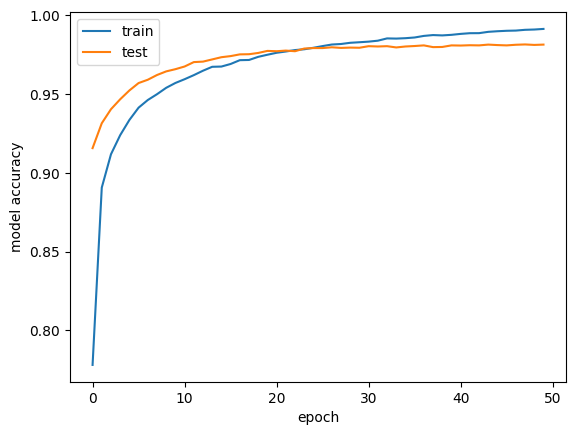

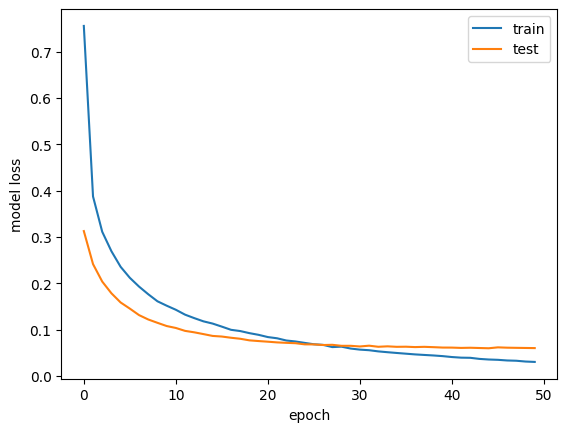

In [14]:

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

## 3.3 evaluating CNN generalization

In this section the ability of the CNN to generalize on unseen data has been tested by making it predict mine handwritten digits.

Since these images ar in principle very different from the MNIST ones (not perfectly centered, different allignments, different shape, and my bad handwriting), the performance is poorer than on the validation dataset. Although, the CNN is still able to recognize almost every digit.

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


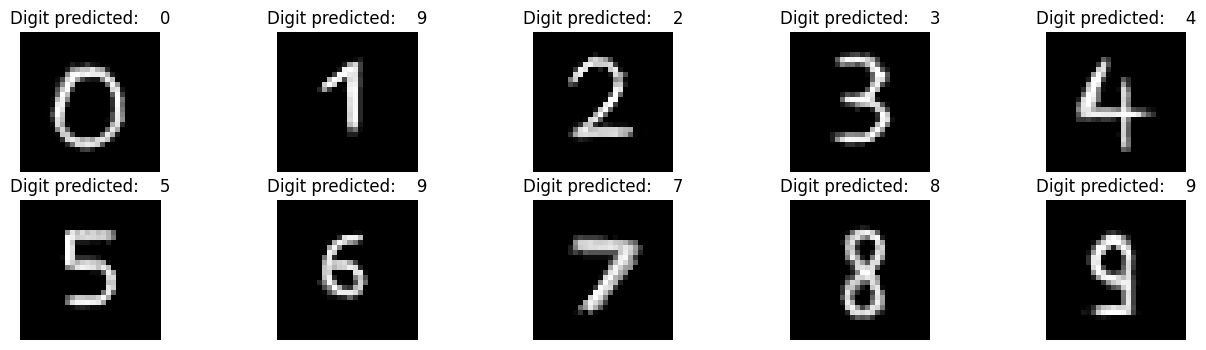

In [35]:

fig, ax=plt.subplots(2,5, figsize=(16,4))
ax=ax.flatten()
for i in range (10):
    digit_in = Image.open(f"{i}.png").convert('L')
    ydim, xdim = digit_in.size
    pix=digit_in.load()
    data = np.zeros((xdim, ydim))
    for j in range(ydim):
        for k in range(xdim):
            data[k,j]=pix[j,k]

    data /= 255
    data = data.reshape(1,xdim*ydim)
    print(data.shape)
    pred = model_DNN.predict(data)

    data = data.reshape(xdim,ydim)
    

    ax[i].imshow(data, cmap='gray')    
    ax[i].set_title("Digit predicted:    {}".format(np.argmax(pred)))
    ax[i].axis('off') 
plt.show()